In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from modlamp.descriptors import PeptideDescriptor, GlobalDescriptor
import warnings
warnings.filterwarnings("ignore")


In [15]:
df_res = pd.read_pickle("../data/attack_results.pkl")
df_adv = df_res[df_res["flipped"]].copy().reset_index(drop=True)
print(f"Adversarially flipped sequences to validate: {len(df_adv)}")

Adversarially flipped sequences to validate: 372


In [16]:
### Compute net charge, Boman index, and hydrophobic moment for each sequence.

def compute_descriptors(seq_list):
    records = []
    for seq in seq_list:
        try:
            gd = GlobalDescriptor([seq])
            gd.calculate_charge(ph=7.0, amide=True)
            charge = gd.descriptor[0][0]

            gd2 = GlobalDescriptor([seq])
            gd2.boman_index()
            boman = gd2.descriptor[0][0]

            pd_h = PeptideDescriptor([seq], "eisenberg")
            pd_h.calculate_moment(window=min(len(seq), 11))
            hm = pd_h.descriptor[0][0]

            records.append({"net_charge": charge,
                             "boman_index": boman,
                             "hydrophobic_moment": hm})
        except Exception:
            records.append({"net_charge": np.nan,
                             "boman_index": np.nan,
                             "hydrophobic_moment": np.nan})
    return pd.DataFrame(records)

In [17]:
print("Computing descriptors for original sequences …")
orig_desc = compute_descriptors(df_adv["original_seq"].tolist())
orig_desc.columns = [c + "_orig" for c in orig_desc.columns]

print("Computing descriptors for adversarial sequences …")
adv_desc = compute_descriptors(df_adv["adv_seq"].tolist())
adv_desc.columns = [c + "_adv" for c in adv_desc.columns]

df_valid = pd.concat([df_adv[["original_seq","adv_seq","n_mutations","substitutions"]],orig_desc, adv_desc],axis=1)
df_valid


Computing descriptors for original sequences …
Computing descriptors for adversarial sequences …


,original_seq,adv_seq,n_mutations,substitutions,net_charge_orig,boman_index_orig,hydrophobic_moment_orig,net_charge_adv,boman_index_adv,hydrophobic_moment_adv
0,MKSSIFFKLLLLVSLLVVIFRQSYAVADYCNRDADCKRVCLRPYAC...,MWSSIFFWLLLLVSLLVVIFRQWYAVADYCNRDADCKRVCLRPYAC...,3,"[(K, W), (K, W), (S, W)]",7.919,1.575568,0.552099,5.919,1.331364,0.552099
1,GIMSIVKDVAKNAAKEAAKGALSTLSCKLAKTC,GIMSIVVDVDKNAAKEAAKGYLSTLSCKLAKTC,3,"[(A, D), (A, Y), (K, V)]",4.861,0.565758,0.668521,2.861,0.653333,0.549724
2,MKTQLVVLIVALVFMQLFAQSEAFWSTIWNAAKSLIGKRGLRNLDD...,MDTQLVVLIVALVFMQLFAQSEAFWSTIWNAAKSLIGKRGLRNLDD...,1,"[(K, D)]",-3.995,1.237887,0.834934,-5.994,1.282535,0.834934
3,MKFHLFFFILLFGATILTAKKSYPEYGSLDLRKECKMRRGHCKLQC...,MKFHLFFFILLFGATILTACKSYPEYGSLDLRKECKMRRGHYKLQY...,3,"[(K, C), (C, Y), (C, Y)]",7.890,1.407538,0.437395,6.956,1.346154,0.442517
4,MDILKKSLFLVLFLGLVSLSICEEEKRENEDEEKQEDDEQSEMKRA...,MDILKKSLFLVLFLGLVSLSACEEEKRENEDEEKQEDDEQSEMKRA...,3,"[(A, D), (I, A), (G, C)]",-2.958,1.673418,0.514670,-4.025,1.841772,0.514670
...,...,...,...,...,...,...,...,...,...,...
367,MSAQKIYLASLLLFICLVFPQSTAIVCNFEGHCVTSDDCINVCKSG...,MSAQKIYLASLLLFICLVFPWSTVIVCNFEGHCVTSDDCINVCKSG...,2,"[(A, V), (Q, W)]",-0.410,0.467534,0.445528,-0.410,0.329178,0.445528
368,MKLLYLFLAILLAIEEPVISGKRHILRRMGNSGICRASCKKNEQPY...,MKLLYDFDAILLAIEEPVISGKRHILRRMGNSGICRASCKKNEQPY...,2,"[(L, D), (L, D)]",6.760,1.825595,0.689995,4.761,2.150357,0.689995
369,MKFATCFLVSYVLVFLVLSVCKEVEAKELCNRIEDIDGNCDFEGEK...,MWFATCFLVSYVLVFLVLSVCKEVEAKELCNRIEDIDGNCDFEGEK...,2,"[(K, W), (L, G)]",4.624,1.702299,0.649666,3.624,1.657471,0.649666
370,MKSITVICFLALCTVAITSAYPQEPVLADEARPFANSLFDELPEET...,MKSITVICFLALCTVACTSKYPQEPVLADEARPFANSLFDELPEET...,2,"[(I, C), (A, K)]",-0.438,1.286531,0.611488,0.494,1.398776,0.611488


In [18]:
hm_mean = orig_desc["hydrophobic_moment_orig"].mean()
hm_std  = orig_desc["hydrophobic_moment_orig"].std()
print(f"Hydrophobic moment — mean: {hm_mean:.3f}, SD: {hm_std:.3f}")
print(f"Accepted range: [{hm_mean - hm_std:.3f},  {hm_mean + hm_std:.3f}]")


Hydrophobic moment — mean: 0.588, SD: 0.134
Accepted range: [0.454,  0.722]


In [19]:
def is_model_failure(row):
    charge_ok = row["net_charge_adv"] >= 2.0
    boman_ok = row["boman_index_adv"] > 1.0
    hm_lo = hm_mean - hm_std
    hm_hi = hm_mean + hm_std
    hm_ok = hm_lo <= row["hydrophobic_moment_adv"] <= hm_hi
    return bool(charge_ok and boman_ok and hm_ok)


df_valid["model_failure"] = df_valid.apply(is_model_failure, axis=1)

n_total = len(df_valid)
n_failures = int(df_valid["model_failure"].sum())

print(f"Attacks analysed : {n_total}")
print(f"Genuine model failures : {n_failures}  ({n_failures/n_total*100:.1f}%)")
print(f"Net charge ≥ 2 : {(df_valid['net_charge_adv']>=2).sum()}"
      f"({(df_valid['net_charge_adv']>=2).mean()*100:.1f}%)")
print(f"Boman index > 1 : {(df_valid['boman_index_adv']>1).sum()}"
      f"({(df_valid['boman_index_adv']>1).mean()*100:.1f}%)")
hm_pass = ((df_valid["hydrophobic_moment_adv"] >= hm_mean - hm_std) &
           (df_valid["hydrophobic_moment_adv"] <= hm_mean + hm_std))
print(f"Hydrophobic moment in 1 SD  : {hm_pass.sum()}  ({hm_pass.mean()*100:.1f}%)")

df_valid.to_pickle("../data/bio_validation_results.pkl")



Attacks analysed : 372
Genuine model failures : 63  (16.9%)
Net charge ≥ 2 : 173(46.5%)
Boman index > 1 : 184(49.5%)
Hydrophobic moment in 1 SD  : 248  (66.7%)


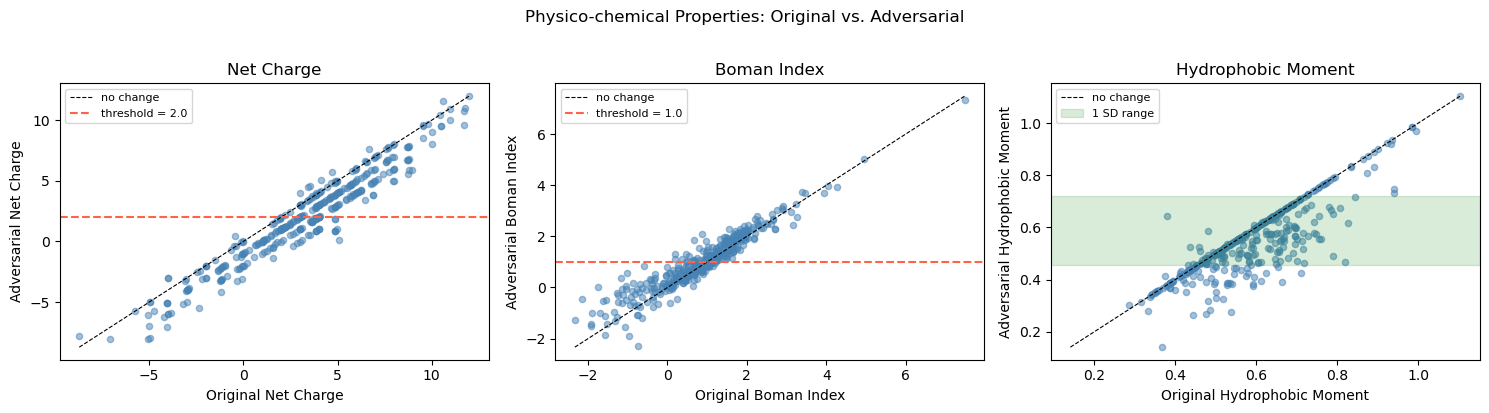

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

props = [
    ("net_charge", "Net Charge", 2.0,  None),
    ("boman_index","Boman Index", 1.0,  None),
    ("hydrophobic_moment", "Hydrophobic Moment", None, (hm_mean-hm_std, hm_mean+hm_std)),
]

for ax, (prop, label, threshold, band) in zip(axes, props):
    orig = df_valid[f"{prop}_orig"].dropna()
    adv = df_valid[f"{prop}_adv"].dropna()
    common = orig.index.intersection(adv.index)
    orig, adv = orig.loc[common], adv.loc[common]

    ax.scatter(orig, adv, alpha=0.5, s=20, color="steelblue")
    lo = min(orig.min(), adv.min())
    hi = max(orig.max(), adv.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, label="no change")
    if threshold is not None:
        ax.axhline(threshold, color="tomato", linestyle="--",label=f"threshold = {threshold}")
    if band is not None:
        ax.axhspan(band[0], band[1], alpha=0.15, color="green", label="1 SD range")
    ax.set_xlabel(f"Original {label}")
    ax.set_ylabel(f"Adversarial {label}")
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle("Physico-chemical Properties: Original vs. Adversarial", y=1.02)
plt.tight_layout()
plt.savefig("../results/figures/03_bio_validation.png", dpi=150, bbox_inches="tight")
plt.show()


In [21]:
summary = pd.DataFrame({
    "Criterion" : ["Net Charge ≥ 2.0", "Boman Index > 1.0", "HM within 1 SD"],
    "Original pass %" : [
        f"{(df_valid['net_charge_orig']>=2).mean()*100:.1f}%",
        f"{(df_valid['boman_index_orig']>1).mean()*100:.1f}%",
        f"{((df_valid['hydrophobic_moment_orig']>=hm_mean-hm_std)&(df_valid['hydrophobic_moment_orig']<=hm_mean+hm_std)).mean()*100:.1f}%",
    ],
    "Adversarial pass %": [
        f"{(df_valid['net_charge_adv']>=2).mean()*100:.1f}%",
        f"{(df_valid['boman_index_adv']>1).mean()*100:.1f}%",
        f"{hm_pass.mean()*100:.1f}%",
    ],
})
print(summary.to_string(index=False))
summary.to_csv("../results/tables/03_bio_validation_summary.csv", index=False)


        Criterion Original pass % Adversarial pass %
 Net Charge ≥ 2.0           66.7%              46.5%
Boman Index > 1.0           46.0%              49.5%
   HM within 1 SD           70.7%              66.7%


In [22]:
df_valid

,original_seq,adv_seq,n_mutations,substitutions,net_charge_orig,boman_index_orig,hydrophobic_moment_orig,net_charge_adv,boman_index_adv,hydrophobic_moment_adv,model_failure
0,MKSSIFFKLLLLVSLLVVIFRQSYAVADYCNRDADCKRVCLRPYAC...,MWSSIFFWLLLLVSLLVVIFRQWYAVADYCNRDADCKRVCLRPYAC...,3,"[(K, W), (K, W), (S, W)]",7.919,1.575568,0.552099,5.919,1.331364,0.552099,True
1,GIMSIVKDVAKNAAKEAAKGALSTLSCKLAKTC,GIMSIVVDVDKNAAKEAAKGYLSTLSCKLAKTC,3,"[(A, D), (A, Y), (K, V)]",4.861,0.565758,0.668521,2.861,0.653333,0.549724,False
2,MKTQLVVLIVALVFMQLFAQSEAFWSTIWNAAKSLIGKRGLRNLDD...,MDTQLVVLIVALVFMQLFAQSEAFWSTIWNAAKSLIGKRGLRNLDD...,1,"[(K, D)]",-3.995,1.237887,0.834934,-5.994,1.282535,0.834934,False
3,MKFHLFFFILLFGATILTAKKSYPEYGSLDLRKECKMRRGHCKLQC...,MKFHLFFFILLFGATILTACKSYPEYGSLDLRKECKMRRGHYKLQY...,3,"[(K, C), (C, Y), (C, Y)]",7.890,1.407538,0.437395,6.956,1.346154,0.442517,False
4,MDILKKSLFLVLFLGLVSLSICEEEKRENEDEEKQEDDEQSEMKRA...,MDILKKSLFLVLFLGLVSLSACEEEKRENEDEEKQEDDEQSEMKRA...,3,"[(A, D), (I, A), (G, C)]",-2.958,1.673418,0.514670,-4.025,1.841772,0.514670,False
...,...,...,...,...,...,...,...,...,...,...,...
367,MSAQKIYLASLLLFICLVFPQSTAIVCNFEGHCVTSDDCINVCKSG...,MSAQKIYLASLLLFICLVFPWSTVIVCNFEGHCVTSDDCINVCKSG...,2,"[(A, V), (Q, W)]",-0.410,0.467534,0.445528,-0.410,0.329178,0.445528,False
368,MKLLYLFLAILLAIEEPVISGKRHILRRMGNSGICRASCKKNEQPY...,MKLLYDFDAILLAIEEPVISGKRHILRRMGNSGICRASCKKNEQPY...,2,"[(L, D), (L, D)]",6.760,1.825595,0.689995,4.761,2.150357,0.689995,True
369,MKFATCFLVSYVLVFLVLSVCKEVEAKELCNRIEDIDGNCDFEGEK...,MWFATCFLVSYVLVFLVLSVCKEVEAKELCNRIEDIDGNCDFEGEK...,2,"[(K, W), (L, G)]",4.624,1.702299,0.649666,3.624,1.657471,0.649666,True
370,MKSITVICFLALCTVAITSAYPQEPVLADEARPFANSLFDELPEET...,MKSITVICFLALCTVACTSKYPQEPVLADEARPFANSLFDELPEET...,2,"[(I, C), (A, K)]",-0.438,1.286531,0.611488,0.494,1.398776,0.611488,False
